# 1 Dataset Analysis

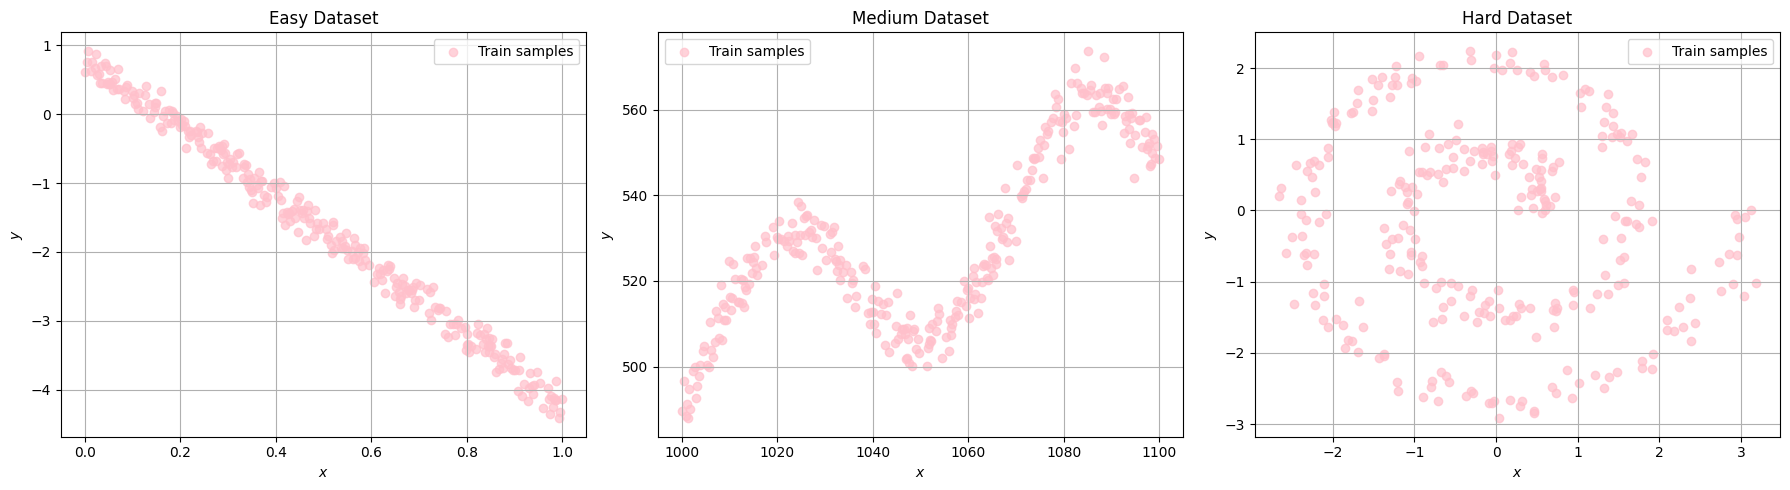

In [49]:
import numpy as np
import matplotlib.pyplot as plt

def load_dataset(train_path, test_path):
    train = np.loadtxt(train_path)
    test = np.loadtxt(test_path)
    x_train, y_train = train[:, 0], train[:, 1]
    x_test, y_test = test[:, 0], test[:, 1]
    return x_train, y_train, x_test, y_test

def plot_1d_dataset(x, y, title, ax):
    ax.scatter(x, y, color='pink', alpha=0.7, label='Train samples')
    ax.set_title(title)
    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.grid(True)
    ax.legend()

# Load datasets from data/ folder
easy_x, easy_y, _, _     = load_dataset("data/easy_train.txt", "data/easy_test.txt")
medium_x, medium_y, _, _ = load_dataset("data/medium_train.txt", "data/medium_test.txt")
hard_x, hard_y, _, _     = load_dataset("data/hard_train.txt", "data/hard_test.txt")

# Plot all three datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_1d_dataset(easy_x, easy_y, "Easy Dataset", axes[0])
plot_1d_dataset(medium_x, medium_y, "Medium Dataset", axes[1])
plot_1d_dataset(hard_x, hard_y, "Hard Dataset", axes[2])
plt.tight_layout()
plt.show()


# 2 Model Implementation

In [51]:
import numpy as np

# Activation functions and their derivatives
activation_functions = {
    'sigmoid': lambda x: 1 / (1 + np.exp(-np.clip(x, -500, 500))),
    'tanh': np.tanh,
    'relu': lambda x: np.maximum(0, x),
}

activation_derivatives = {
    'sigmoid': lambda x: activation_functions['sigmoid'](x) * (1 - activation_functions['sigmoid'](x)),
    'tanh': lambda x: 1 - np.tanh(x) ** 2,
    'relu': lambda x: (x > 0).astype(float),
}


# Single Layer Perceptron (SLP)
class SingleLayerPerceptron:
    def __init__(self, input_dim, learning_rate=0.01, momentum=0.0, weight_range=1.0):
        self.lr = learning_rate
        self.momentum = momentum
        self.w = np.random.uniform(-weight_range, weight_range, size=(input_dim,))
        self.b = 0.0
        self.v_w = np.zeros_like(self.w)
        self.v_b = 0.0

    def predict(self, x):
        return np.dot(x, self.w) + self.b

    def _train_step(self, x_batch, y_batch):
        y_pred = self.predict(x_batch)
        error = y_pred - y_batch
        grad_w = (2 / len(x_batch)) * np.dot(x_batch.T, error)
        grad_b = (2 / len(x_batch)) * np.sum(error)

        if self.momentum > 0:
            self.v_w = self.momentum * self.v_w + (1 - self.momentum) * grad_w
            self.v_b = self.momentum * self.v_b + (1 - self.momentum) * grad_b
            self.w -= self.lr * self.v_w
            self.b -= self.lr * self.v_b
        else:
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

    def train(self, x, y, epochs=2000, batch_size=16, verbose=False):
        for epoch in range(epochs):
            indices = np.random.permutation(len(x))
            x_shuffled, y_shuffled = x[indices], y[indices]
            for i in range(0, len(x), batch_size):
                x_batch = x_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                self._train_step(x_batch, y_batch)


# Multi Layer Perceptron (MLP)
class MultiLayerPerceptron:
    def __init__(self, input_dim, hidden_size, activation='relu', learning_rate=0.01, momentum=0.0, weight_range=1.0):
        self.lr = learning_rate
        self.momentum = momentum
        self.activation = activation_functions[activation]
        self.act_deriv = activation_derivatives[activation]

        self.W1 = np.random.uniform(-weight_range, weight_range, (input_dim, hidden_size))
        self.b1 = np.zeros(hidden_size)
        self.W2 = np.random.uniform(-weight_range, weight_range, (hidden_size, 1))
        self.b2 = 0.0

        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = 0.0

    def predict(self, x):
        z1 = np.dot(x, self.W1) + self.b1
        a1 = self.activation(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        return z2.flatten()

    def _train_step(self, x_batch, y_batch):
        # Forward
        z1 = np.dot(x_batch, self.W1) + self.b1
        a1 = self.activation(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        y_pred = z2.flatten()

        # Backward
        error = y_pred - y_batch
        dz2 = (2 / len(x_batch)) * error.reshape(-1, 1)
        grad_W2 = np.dot(a1.T, dz2)
        grad_b2 = np.sum(dz2)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.act_deriv(z1)
        grad_W1 = np.dot(x_batch.T, dz1)
        grad_b1 = np.sum(dz1, axis=0)

        # Update
        if self.momentum > 0:
            self.v_W1 = self.momentum * self.v_W1 + (1 - self.momentum) * grad_W1
            self.v_b1 = self.momentum * self.v_b1 + (1 - self.momentum) * grad_b1
            self.v_W2 = self.momentum * self.v_W2 + (1 - self.momentum) * grad_W2
            self.v_b2 = self.momentum * self.v_b2 + (1 - self.momentum) * grad_b2

            self.W1 -= self.lr * self.v_W1
            self.b1 -= self.lr * self.v_b1
            self.W2 -= self.lr * self.v_W2
            self.b2 -= self.lr * self.v_b2
        else:
            self.W1 -= self.lr * grad_W1
            self.b1 -= self.lr * grad_b1
            self.W2 -= self.lr * grad_W2
            self.b2 -= self.lr * grad_b2

    def train(self, x, y, epochs=2000, batch_size=16, verbose=False):
        for epoch in range(epochs):
            indices = np.random.permutation(len(x))
            x_shuffled, y_shuffled = x[indices], y[indices]
            for i in range(0, len(x), batch_size):
                x_batch = x_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]
                self._train_step(x_batch, y_batch)


# 3 Analysis of Hyperparameters

In [52]:
import itertools
from sklearn.metrics import mean_squared_error

def run_slp_grid(x_train, y_train, x_test, y_test):
    best_mse = float('inf')
    best_config = None
    best_model = None

    learning_rates = [0.01, 0.1, 1.0]
    momentums = [0.0, 0.5, 0.9]

    print("🔍 Evaluating SLP configurations...")

    for lr, momentum in itertools.product(learning_rates, momentums):
        model = SingleLayerPerceptron(input_dim=1, learning_rate=lr, momentum=momentum)
        try:
            mse, _ = evaluate_model(model, x_train, y_train, x_test, y_test)
        except Exception as e:
            print(f"❌ Failed config: lr={lr}, momentum={momentum}, error={e}")
            continue

        print(f"✅ SLP | lr={lr}, momentum={momentum:.1f} | Test MSE: {mse:.5f}")

        if mse < best_mse:
            best_mse = mse
            best_config = (lr, momentum)
            best_model = model

    if best_model is None:
        print("⚠️ No SLP configuration converged. Using default: lr=0.01, momentum=0.0")
        best_model = SingleLayerPerceptron(input_dim=1, learning_rate=0.01, momentum=0.0)
        best_model.train(x_train, y_train, epochs=2000, batch_size=16, verbose=False)
        best_config = (0.01, 0.0)
        best_mse = mean_squared_error(y_test, best_model.predict(x_test))

    return best_model, best_config, best_mse


In [53]:
def run_mlp_grid(x_train, y_train, x_test, y_test):
    best_mse = float('inf')
    best_config = None
    best_model = None

    learning_rates = [0.01, 0.1, 1.0]
    momentums = [0.0, 0.5, 0.9]
    hidden_sizes = [4, 8, 16]
    activations = ['sigmoid', 'tanh', 'relu']

    print("🔍 Evaluating MLP configurations...")

    for lr, momentum, hidden_size, activation in itertools.product(learning_rates, momentums, hidden_sizes, activations):
        model = MultiLayerPerceptron(input_dim=1, hidden_size=hidden_size,
                                     activation=activation, learning_rate=lr,
                                     momentum=momentum)
        try:
            mse, _ = evaluate_model(model, x_train, y_train, x_test, y_test)
        except Exception as e:
            print(f"❌ Failed config: lr={lr}, momentum={momentum}, hidden={hidden_size}, act={activation}, error={e}")
            continue

        print(f"✅ MLP | lr={lr}, mom={momentum:.1f}, hid={hidden_size}, act={activation} | Test MSE: {mse:.5f}")

        if mse < best_mse:
            best_mse = mse
            best_config = (lr, momentum, hidden_size, activation)
            best_model = model

    if best_model is None:
        print("⚠️ No MLP configuration converged. Using default: lr=0.01, mom=0.0, hid=4, act=sigmoid")
        best_model = MultiLayerPerceptron(input_dim=1, hidden_size=4, activation='sigmoid',
                                          learning_rate=0.01, momentum=0.0)
        best_model.train(x_train, y_train, epochs=2000, batch_size=16, verbose=False)
        best_config = (0.01, 0.0, 4, 'sigmoid')
        best_mse = mean_squared_error(y_test, best_model.predict(x_test))

    return best_model, best_config, best_mse


In [54]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    model.train(x_train, y_train, epochs=2000, batch_size=16, verbose=False)
    y_pred = model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse, y_pred


In [55]:
def plot_side_by_side(model1, model2, x_train, y_train, x_test, y_test, label1="SLP", label2="MLP"):
    x_dense = np.linspace(min(x_train.min(), x_test.min()),
                          max(x_train.max(), x_test.max()), 200).reshape(-1, 1)

    y_pred1 = model1.predict(x_dense)
    y_pred2 = model2.predict(x_dense)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    axes[0].scatter(x_train, y_train, color='blue', alpha=0.6, label='Train')
    axes[0].scatter(x_test, y_test, color='green', alpha=0.6, label='Test')
    axes[0].plot(x_dense, y_pred1, color='red', linewidth=2, label='Prediction')
    axes[0].set_title(f'{label1} Prediction Curve')
    axes[0].set_xlabel('$x$')
    axes[0].set_ylabel('$y$')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].scatter(x_train, y_train, color='blue', alpha=0.6, label='Train')
    axes[1].scatter(x_test, y_test, color='green', alpha=0.6, label='Test')
    axes[1].plot(x_dense, y_pred2, color='red', linewidth=2, label='Prediction')
    axes[1].set_title(f'{label2} Prediction Curve')
    axes[1].set_xlabel('$x$')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [56]:
# Reshape inputs to 2D
easy_x_train = easy_x.reshape(-1, 1)
easy_x_test = np.loadtxt("data/easy_test.txt")[:, 0].reshape(-1, 1)
easy_y_test = np.loadtxt("data/easy_test.txt")[:, 1]

# Run grid search
best_slp_easy, slp_config_easy, slp_mse_easy = run_slp_grid(
    easy_x_train, easy_y, easy_x_test, easy_y_test
)

best_mlp_easy, mlp_config_easy, mlp_mse_easy = run_mlp_grid(
    easy_x_train, easy_y, easy_x_test, easy_y_test
)

# Log best models
print("\n✅ Best SLP on Easy:")
print(f"  MSE: {slp_mse_easy:.4f}")
print(f"  Config: lr={slp_config_easy[0]}, momentum={slp_config_easy[1]}")

print("\n✅ Best MLP on Easy:")
print(f"  MSE: {mlp_mse_easy:.4f}")
print(f"  Config: lr={mlp_config_easy[0]}, momentum={mlp_config_easy[1]}, "
      f"hidden={mlp_config_easy[2]}, activation={mlp_config_easy[3]}")


🔍 Evaluating SLP configurations...
✅ SLP | lr=0.01, momentum=0.0 | Test MSE: 0.02271
✅ SLP | lr=0.01, momentum=0.5 | Test MSE: 0.02272
✅ SLP | lr=0.01, momentum=0.9 | Test MSE: 0.02276
✅ SLP | lr=0.1, momentum=0.0 | Test MSE: 0.02262
✅ SLP | lr=0.1, momentum=0.5 | Test MSE: 0.02275
✅ SLP | lr=0.1, momentum=0.9 | Test MSE: 0.02294


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-51-c14b62abf397>:43: RuntimeWarning: invalid value encountered in scalar subtract
  self.b -= self.lr * grad_b


❌ Failed config: lr=1.0, momentum=0.0, error=Input contains NaN.
✅ SLP | lr=1.0, momentum=0.5 | Test MSE: 0.02282
✅ SLP | lr=1.0, momentum=0.9 | Test MSE: 0.02437
🔍 Evaluating MLP configurations...
✅ MLP | lr=0.01, mom=0.0, hid=4, act=sigmoid | Test MSE: 0.02486
✅ MLP | lr=0.01, mom=0.0, hid=4, act=tanh | Test MSE: 0.02302
✅ MLP | lr=0.01, mom=0.0, hid=4, act=relu | Test MSE: 0.02284
✅ MLP | lr=0.01, mom=0.0, hid=8, act=sigmoid | Test MSE: 0.02378
✅ MLP | lr=0.01, mom=0.0, hid=8, act=tanh | Test MSE: 0.02342
✅ MLP | lr=0.01, mom=0.0, hid=8, act=relu | Test MSE: 0.02295
✅ MLP | lr=0.01, mom=0.0, hid=16, act=sigmoid | Test MSE: 0.02293
✅ MLP | lr=0.01, mom=0.0, hid=16, act=tanh | Test MSE: 0.02329
✅ MLP | lr=0.01, mom=0.0, hid=16, act=relu | Test MSE: 0.02302
✅ MLP | lr=0.01, mom=0.5, hid=4, act=sigmoid | Test MSE: 0.02385
✅ MLP | lr=0.01, mom=0.5, hid=4, act=tanh | Test MSE: 0.02297
✅ MLP | lr=0.01, mom=0.5, hid=4, act=relu | Test MSE: 0.02329
✅ MLP | lr=0.01, mom=0.5, hid=8, act=sigmoi

<ipython-input-51-c14b62abf397>:93: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.0, hidden=4, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.0, hid=4, act=relu | Test MSE: 35620.02325
✅ MLP | lr=1.0, mom=0.0, hid=8, act=sigmoid | Test MSE: 17729.43505


...

❌ Failed config: lr=1.0, momentum=0.5, hidden=4, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=4, act=relu | Test MSE: 2.27027
✅ MLP | lr=1.0, mom=0.5, hid=8, act=sigmoid | Test MSE: 0.03717


<ipython-input-51-c14b62abf397>:93: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=8, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=8, act=relu | Test MSE: 2.22457
✅ MLP | lr=1.0, mom=0.5, hid=16, act=sigmoid | Test MSE: 0.02517


<ipython-input-51-c14b62abf397>:93: RuntimeWarning: invalid value encountered in multiply
  dz1 = da1 * self.act_deriv(z1)


❌ Failed config: lr=1.0, momentum=0.5, hidden=16, act=tanh, error=Input contains NaN.
✅ MLP | lr=1.0, mom=0.5, hid=16, act=relu | Test MSE: 2.23830
✅ MLP | lr=1.0, mom=0.9, hid=4, act=sigmoid | Test MSE: 0.02548
✅ MLP | lr=1.0, mom=0.9, hid=4, act=tanh | Test MSE: 0.02982
✅ MLP | lr=1.0, mom=0.9, hid=4, act=relu | Test MSE: 0.02992
✅ MLP | lr=1.0, mom=0.9, hid=8, act=sigmoid | Test MSE: 0.02823
✅ MLP | lr=1.0, mom=0.9, hid=8, act=tanh | Test MSE: 0.02370
✅ MLP | lr=1.0, mom=0.9, hid=8, act=relu | Test MSE: 2.26406
✅ MLP | lr=1.0, mom=0.9, hid=16, act=sigmoid | Test MSE: 0.02362
✅ MLP | lr=1.0, mom=0.9, hid=16, act=tanh | Test MSE: 0.04000
✅ MLP | lr=1.0, mom=0.9, hid=16, act=relu | Test MSE: 0.03025

✅ Best SLP on Easy:
  MSE: 0.0226
  Config: lr=0.1, momentum=0.0

✅ Best MLP on Easy:
  MSE: 0.0227
  Config: lr=0.01, momentum=0.9, hidden=16, activation=sigmoid


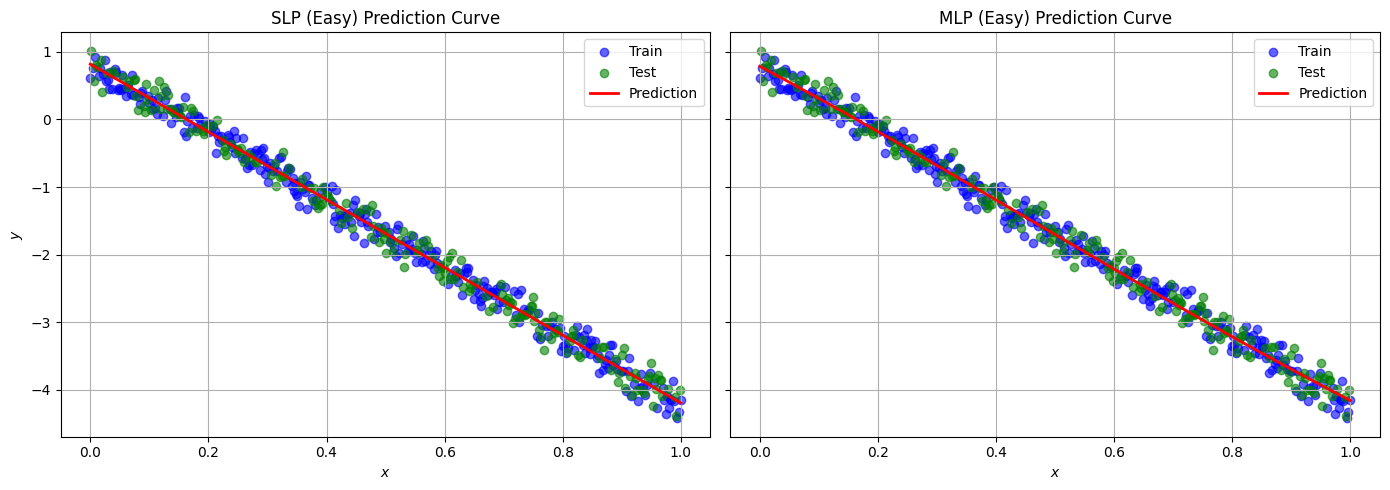

In [57]:
# Plot predictions for easy dataset
plot_side_by_side(
    model1=best_slp_easy,
    model2=best_mlp_easy,
    x_train=easy_x_train,
    y_train=easy_y,
    x_test=easy_x_test,
    y_test=easy_y_test,
    label1="SLP (Easy)",
    label2="MLP (Easy)"
)


In [60]:

# Prepare medium dataset
medium_x_train = medium_x.reshape(-1, 1)
medium_x_test = np.loadtxt("data/medium_test.txt")[:, 0].reshape(-1, 1)
medium_y_test = np.loadtxt("data/medium_test.txt")[:, 1]

# Run grid search
best_slp_medium, slp_config_medium, slp_mse_medium = run_slp_grid(
    medium_x_train, medium_y, medium_x_test, medium_y_test
)

best_mlp_medium, mlp_config_medium, mlp_mse_medium = run_mlp_grid(
    medium_x_train, medium_y, medium_x_test, medium_y_test
)

# Log best models
print("\n✅ Best SLP on Medium:")
print(f"  MSE: {slp_mse_medium:.4f}")
print(f"  Config: lr={slp_config_medium[0]}, momentum={slp_config_medium[1]}")

print("\n✅ Best MLP on Medium:")
print(f"  MSE: {mlp_mse_medium:.4f}")
print(f"  Config: lr={mlp_config_medium[0]}, momentum={mlp_config_medium[1]}, "
      f"hidden={mlp_config_medium[2]}, activation={mlp_config_medium[3]}")



🔍 Evaluating SLP configurations...


<ipython-input-51-c14b62abf397>:42: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr * grad_w


❌ Failed config: lr=0.01, momentum=0.0, error=Input contains NaN.


<ipython-input-51-c14b62abf397>:37: RuntimeWarning: invalid value encountered in add
  self.v_w = self.momentum * self.v_w + (1 - self.momentum) * grad_w


❌ Failed config: lr=0.01, momentum=0.5, error=Input contains NaN.


...

❌ Failed config: lr=1.0, momentum=0.5, error=Input contains NaN.


/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
<ipython-input-51-c14b62abf397>:37: RuntimeWarning: invalid value encountered in add
  self.v_w = self.momentum * self.v_w + (1 - self.momentum) * grad_w
<ipython-input-51-c14b62abf397>:38: RuntimeWarning: invalid value encountered in scalar add
  self.v_b = self.momentum * self.v_b + (1 - self.momentum) * grad_b


❌ Failed config: lr=1.0, momentum=0.9, error=Input contains NaN.
⚠️ No SLP configuration converged. Using default: lr=0.01, momentum=0.0


<ipython-input-51-c14b62abf397>:42: RuntimeWarning: invalid value encountered in subtract
  self.w -= self.lr * grad_w


ValueError: Input contains NaN.

# 4 Min-Max Scaling

# 5 Effect of Model Complexity